In [553]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from IPython.display import display

In [554]:
df = pd.read_csv("../Dataset/air_traffic_data_new.csv")

In [555]:
df

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


# Data Preparation :-

### How can we handle missing values and anomalies in the dataset?

In [556]:
df.columns = df.columns.str.replace(" ", "")

In [557]:
df

,ActivityPeriod,OperatingAirline,OperatingAirlineIATACode,PublishedAirline,PublishedAirlineIATACode,GEOSummary,GEORegion,ActivityTypeCode,PriceCategoryCode,Terminal,BoardingArea,PassengerCount,AdjustedActivityTypeCode,AdjustedPassengerCount,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


In [558]:
df.dtypes

ActivityPeriod               int64
OperatingAirline            object
OperatingAirlineIATACode    object
PublishedAirline            object
PublishedAirlineIATACode    object
GEOSummary                  object
GEORegion                   object
ActivityTypeCode            object
PriceCategoryCode           object
Terminal                    object
BoardingArea                object
PassengerCount               int64
AdjustedActivityTypeCode    object
AdjustedPassengerCount       int64
Year                         int64
Month                       object
dtype: object

In [559]:
df.isnull().sum()

ActivityPeriod               0
OperatingAirline             0
OperatingAirlineIATACode    54
PublishedAirline             0
PublishedAirlineIATACode    54
GEOSummary                   0
GEORegion                    0
ActivityTypeCode             0
PriceCategoryCode            0
Terminal                     0
BoardingArea                 0
PassengerCount               0
AdjustedActivityTypeCode     0
AdjustedPassengerCount       0
Year                         0
Month                        0
dtype: int64

In [560]:
df.OperatingAirlineIATACode = df.OperatingAirlineIATACode.fillna("Unkown")
df.PublishedAirlineIATACode = df.PublishedAirlineIATACode.fillna("Unkown")

### What transformations are required to convert the Activity Period column into a more usable format ?

In [561]:
df.ActivityPeriod = pd.to_datetime(df.ActivityPeriod,format='%Y%m')

### Cleaning Data

In [562]:
df.OperatingAirline.unique()

array(['ATA Airlines', 'Air Canada ', 'Air China', 'Air France',
       'Air New Zealand', 'AirTran Airways', 'Alaska Airlines',
       'All Nippon Airways', 'American Airlines',
       'American Eagle Airlines', 'Asiana Airlines',
       'Atlantic Southeast Airlines', 'BelAir Airlines',
       'British Airways', 'Cathay Pacific', 'China Airlines',
       'Delta Air Lines', 'EVA Airways', 'Frontier Airlines',
       'Hawaiian Airlines', 'Horizon Air ', 'Icelandair',
       'Independence Air', 'Japan Airlines', 'KLM Royal Dutch Airlines',
       'Korean Air Lines', 'Lufthansa German Airlines', 'Mesa Airlines',
       'Mexicana Airlines', 'Midwest Airlines', 'Northwest Airlines',
       'Philippine Airlines', 'Singapore Airlines', 'SkyWest Airlines',
       'Sun Country Airlines', 'TACA', 'US Airways', 'United Airlines',
       'United Airlines - Pre 07/01/2013', 'Virgin Atlantic',
       'WestJet Airlines', 'Boeing Company', 'Miami Air International',
       'Air Canada Jazz', 'Qantas A

In [563]:
df.OperatingAirline.unique()
df.OperatingAirline = df.OperatingAirline.str.replace("United Airlines - Pre 07/01/2013",'United Airlines')

In [564]:
df

,ActivityPeriod,OperatingAirline,OperatingAirlineIATACode,PublishedAirline,PublishedAirlineIATACode,GEOSummary,GEORegion,ActivityTypeCode,PriceCategoryCode,Terminal,BoardingArea,PassengerCount,AdjustedActivityTypeCode,AdjustedPassengerCount,Year,Month
0,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,2005-07-01,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,2005-07-01,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,2005-07-01,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,2016-03-01,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,2016-03-01,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,2016-03-01,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,2016-03-01,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


# Exploratory Data Analysis (EDA)

#### What are the key statistics for passenger counts, and how are they distributed ?

In [565]:
df.describe()

,ActivityPeriod,PassengerCount,AdjustedPassengerCount,Year
count,15007,15007.000000,15007.000000,15007.000000
mean,2010-11-05 19:37:51.020190464,29240.521090,29331.917105,2010.385220
min,2005-07-01 00:00:00,1.000000,1.000000,2005.000000
25%,2008-03-01 00:00:00,5373.500000,5495.500000,2008.000000
50%,2010-11-01 00:00:00,9210.000000,9354.000000,2010.000000
75%,2013-08-01 00:00:00,21158.500000,21182.000000,2013.000000
max,2016-03-01 00:00:00,659837.000000,659837.000000,2016.000000
std,NaN,58319.509284,58284.182219,3.137589


In [566]:
df.groupby('OperatingAirline')[['PassengerCount']].sum().nlargest(10, 'PassengerCount').reset_index()

,OperatingAirline,PassengerCount
0,United Airlines,170240913
1,SkyWest Airlines,35711737
2,American Airlines,34588714
3,Virgin America,26934738
4,Delta Air Lines,26440420
5,Southwest Airlines,25087141
6,US Airways,16816616
7,Alaska Airlines,12955980
8,JetBlue Airways,7827973
9,Air Canada,6680071


In [567]:
df.groupby('PriceCategoryCode')[['PassengerCount']].sum().nlargest(10, 'PassengerCount').reset_index()

,PriceCategoryCode,PassengerCount
0,Other,363655616
1,Low Fare,75156884


In [568]:
df.groupby('GEORegion')[['PassengerCount']].sum().nlargest(10,'PassengerCount').reset_index()

,GEORegion,PassengerCount
0,US,338141001
1,Asia,43972770
2,Europe,26646558
3,Canada,13865159
4,Mexico,7998587
5,Australia / Oceania,4729341
6,Middle East,1852943
7,Central America,1355400
8,South America,250741


In [569]:
grouped = df.groupby('GEOSummary')[['PassengerCount']].sum()
total = grouped['PassengerCount'].sum()
grouped['Percentage'] = (grouped['PassengerCount']/total) * 100
grouped['Percentage'] = grouped['Percentage'].round(2)
display(grouped)

,PassengerCount,Percentage
GEOSummary,,
Domestic,338141001,77.06
International,100671499,22.94


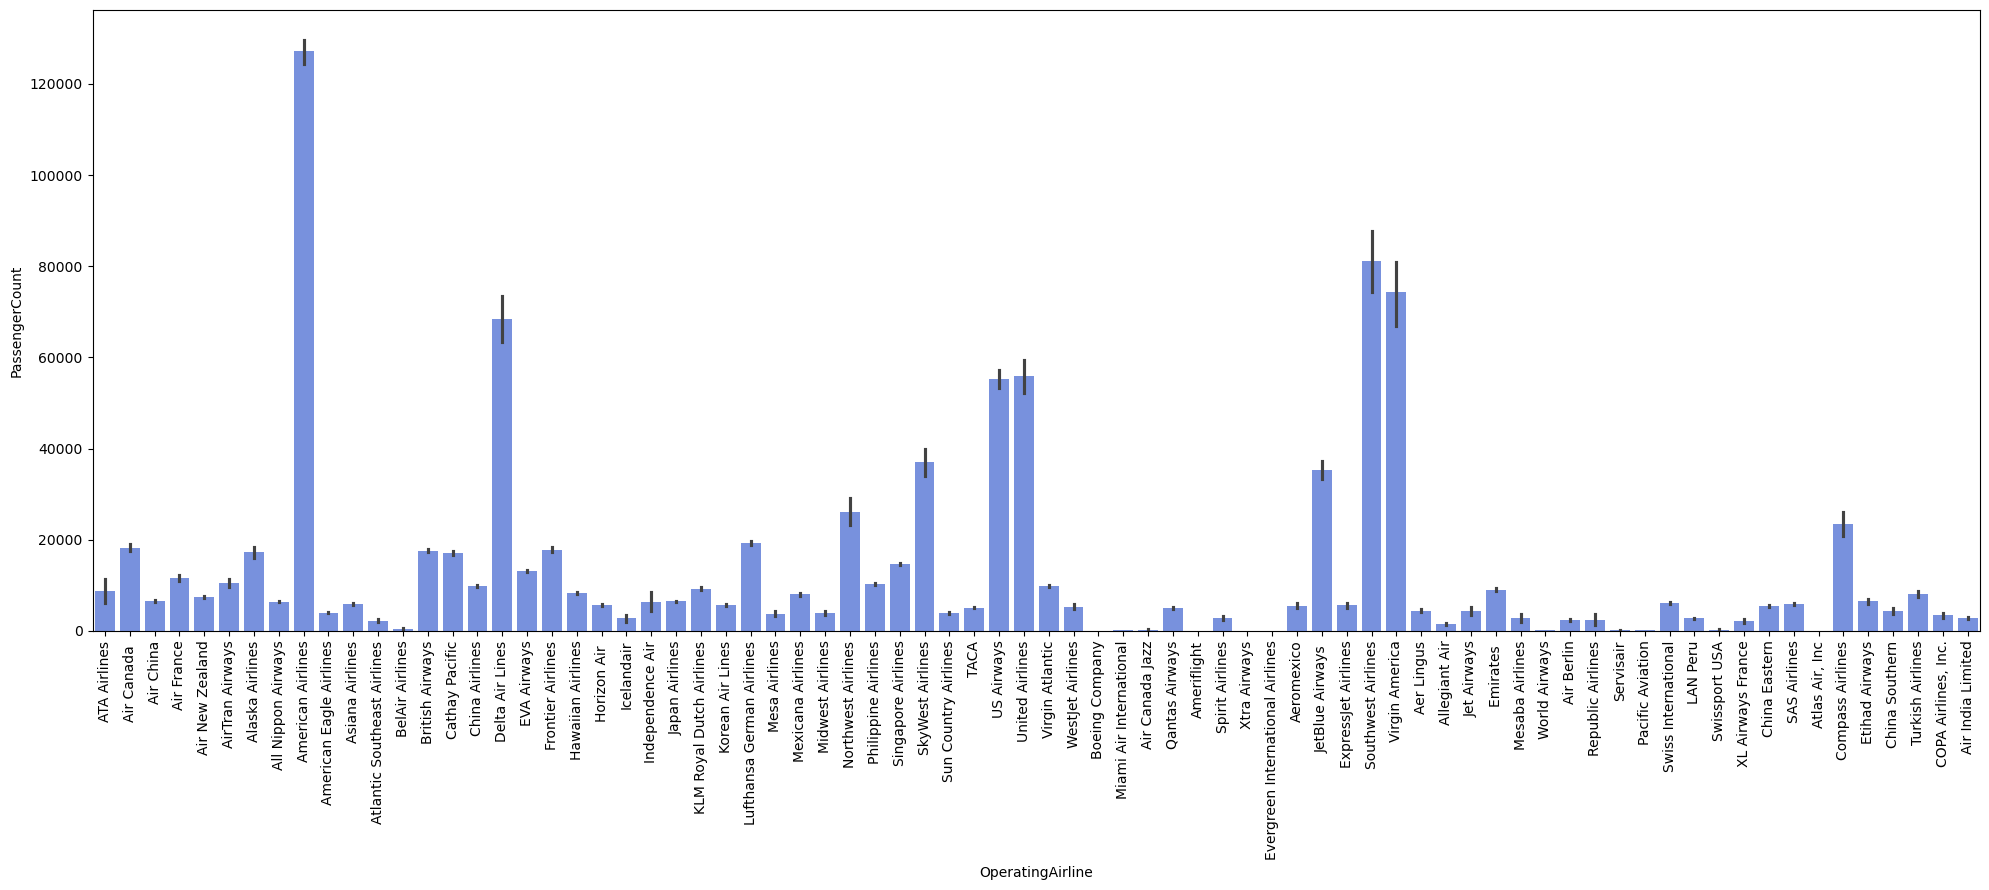

In [570]:
plt.figure(figsize = (20,9))
sb.barplot(x=df.OperatingAirline,y=df.PassengerCount)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

##### Passenger traffic is highest in the US GEORegion, accounting for a significant share of overall volume. In contrast, regions like 'Central America' and 'South America' recorded much lower counts. 

##### Major carriers such as United Airlines and SkyWest Airlines showed consistently high passenger volumes across multiple GEORegions, suggesting broad operational reach

##### Domestic flights accounted for approximately 77% of the total passenger volume, reflecting strong intra-country travel demand. International travel, while smaller in volume.

#### User Centric Dashboard

['US' 'Canada' 'Asia' 'Europe' 'Australia / Oceania' 'Mexico'
 'Central America' 'Middle East' 'South America']


Enter The Region Name:
 Canada


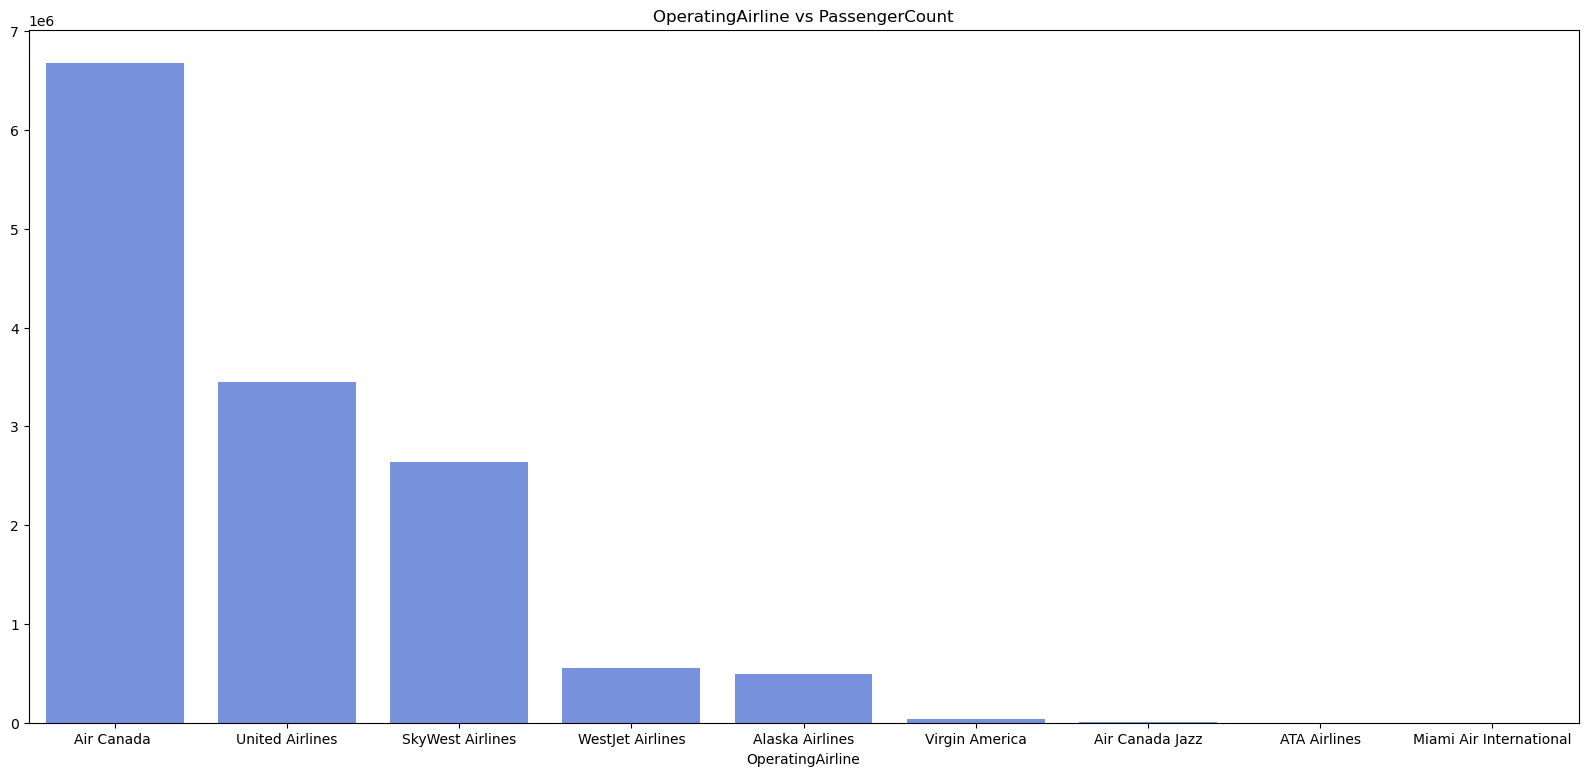

In [581]:
print(df.GEORegion.unique())
ask = input("Enter The Region Name:\n")
d = df[df.GEORegion == ask] # if you use paranthesis in place of square brackets it will throw 'Dataframe' object is not callable Error

mb = d.groupby('OperatingAirline')['PassengerCount'].sum().nlargest(10)
# dm = d.groupby(['Terminal','BoardingArea'])['PassengerCount'].sum().nlargest(10) #-- below syntax to avoid error 'series object is not callable'
# dm = d.groupby(['Terminal','BoardingArea'])['PassengerCount'].sum().reset_index()
# dm = dm.nlargest(10, 'PassengerCount')

plt.figure(figsize = (20,9))
sb.barplot(x = mb.index, y = mb.values)
plt.title("OperatingAirline vs PassengerCount") 
plt.show()

# sb.barplot(x = dm.index, y = dm.values, hue = dm.BoardingArea) #-- here since dm does not contain complete data but only data which we have extracted so 
# # #-- to use it we have to firsr reset index then apply .nlargest on dm follow below syntax to make it correct no throwing error 'series object is not callable'
# plt.title("Terminal/BoardingArea vs PassengerCount")
# plt.xticks(rotation = 90)
# plt.show()

# Correct syntax
# plt.figure(figsize = (20,9))
# sb.barplot(x = dm.BoardingArea, y = dm.PassengerCount, hue = dm.Terminal)
# plt.title("Terminal/Boarding  Area vs Passengr Count")
# plt.xticks(rotation = 90)
# plt.show()

###  Which regions(GEOSummary andGEORegion) have the highest and lowest passenger traffic?

,Top_GEORegion,Top_PassengerCount,Percentage,,Bottom_GEORegion,Bottom_PassengerCount
0,US,338141001,77.06,,South America,250741
1,Asia,43972770,10.02,,Central America,1355400
2,Europe,26646558,6.07,,Middle East,1852943
3,Canada,13865159,3.16,,Australia / Oceania,4729341
4,Mexico,7998587,1.82,,Mexico,7998587
5,Australia / Oceania,4729341,1.08,,Canada,13865159
6,Middle East,1852943,0.42,,Europe,26646558
7,Central America,1355400,0.31,,Asia,43972770
8,South America,250741,0.06,,US,338141001


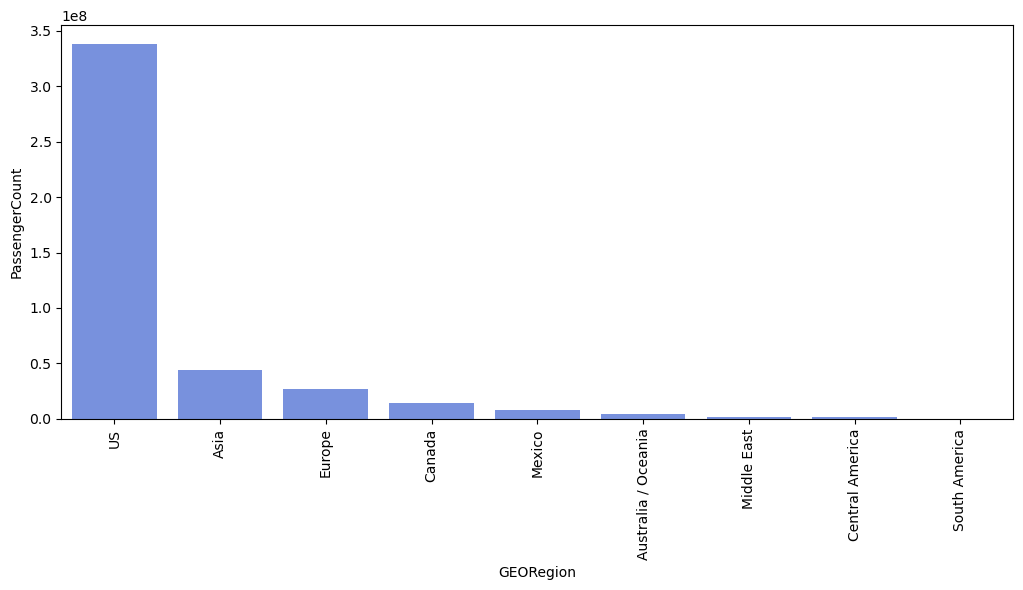

In [584]:
group1 = df.groupby('GEORegion')[['PassengerCount']].sum().nlargest(10, 'PassengerCount').reset_index()
group2 = df.groupby('GEORegion')[['PassengerCount']].sum().nsmallest(10, 'PassengerCount').reset_index()
total = group1['PassengerCount'].sum()
group1['Percentage'] = ((group1['PassengerCount']/total) * 100 )
group1['Percentage'] = group1['Percentage'].round(2)
group1.columns = ['Top_GEORegion', 'Top_PassengerCount', 'Percentage']
group2.columns = ['Bottom_GEORegion', 'Bottom_PassengerCount']
separator = pd.DataFrame({'': [''] * len(group1)})
result = pd.concat([group1, separator,group2], axis = 1)
display(result)

# Plot
group1 = df.groupby('GEORegion')[['PassengerCount']].sum().nlargest(10 ,'PassengerCount').reset_index()
fig = plt.figure(figsize=[20,6])
x1 = fig.add_subplot(121)                 
sb.barplot(x = group1.GEORegion, y = group1.PassengerCount)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

,GEOSummary,PassengerCount
0,Domestic,338141001
1,International,100671499


GEOSummary,Domestic,International
Month,,
August,510,800
July,496,807
September,506,791
October,502,793
January,492,776
November,495,768
December,486,773
February,477,778
March,478,775


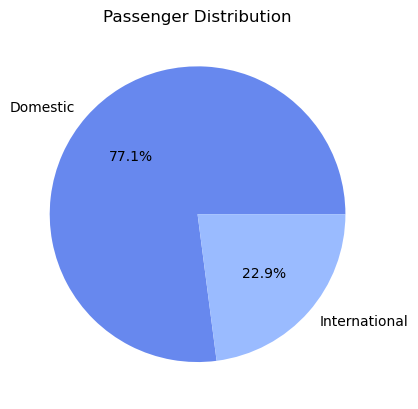

In [500]:
all_count = df.groupby('GEOSummary')[['PassengerCount']].sum().nlargest(10, 'PassengerCount').reset_index()
display(all_count)
# Month wise geosummary count
# domestic_count = df[df['GEOSummary'] == 'Domestic'].groupby('Month').size().reset_index(name='Domestic_Count')
# display(domestic_count)
flight_counts = df.groupby(['Month', 'GEOSummary']).size().unstack().fillna(0)
flight_counts['Total'] = flight_counts.sum(axis=1)
top_months = flight_counts.sort_values('Total', ascending=False).head(10)
final_table = top_months.drop(columns='Total')
display(final_table)

# result = pd.concat([all_count, final_table], axis = 1)
# display(result)

colors = sb.set_palette('coolwarm')
plt.pie(a.PassengerCount, labels = a.GEOSummary, colors = colors, autopct='%1.1f%%')
plt.title('Passenger Distribution')
plt.show()

##### Region US experienced the highest passenger traffic, contributing 77% of total volume. In contrast, Region South America had the lowest, possibly due to less traffic, fewer connections, or geographical factors

##### Among all categories in GEOSummary, Domestic flights recorded the highest passenger count. where as International flights recorded hightest flight counts This indicates a travel trend favoring internal flights with more passenger volumes and international flights with low passsenger count but higher flights observed.

### How do the different activity types (Deplaned, Enplaned, etc.) contribute to passenger counts?

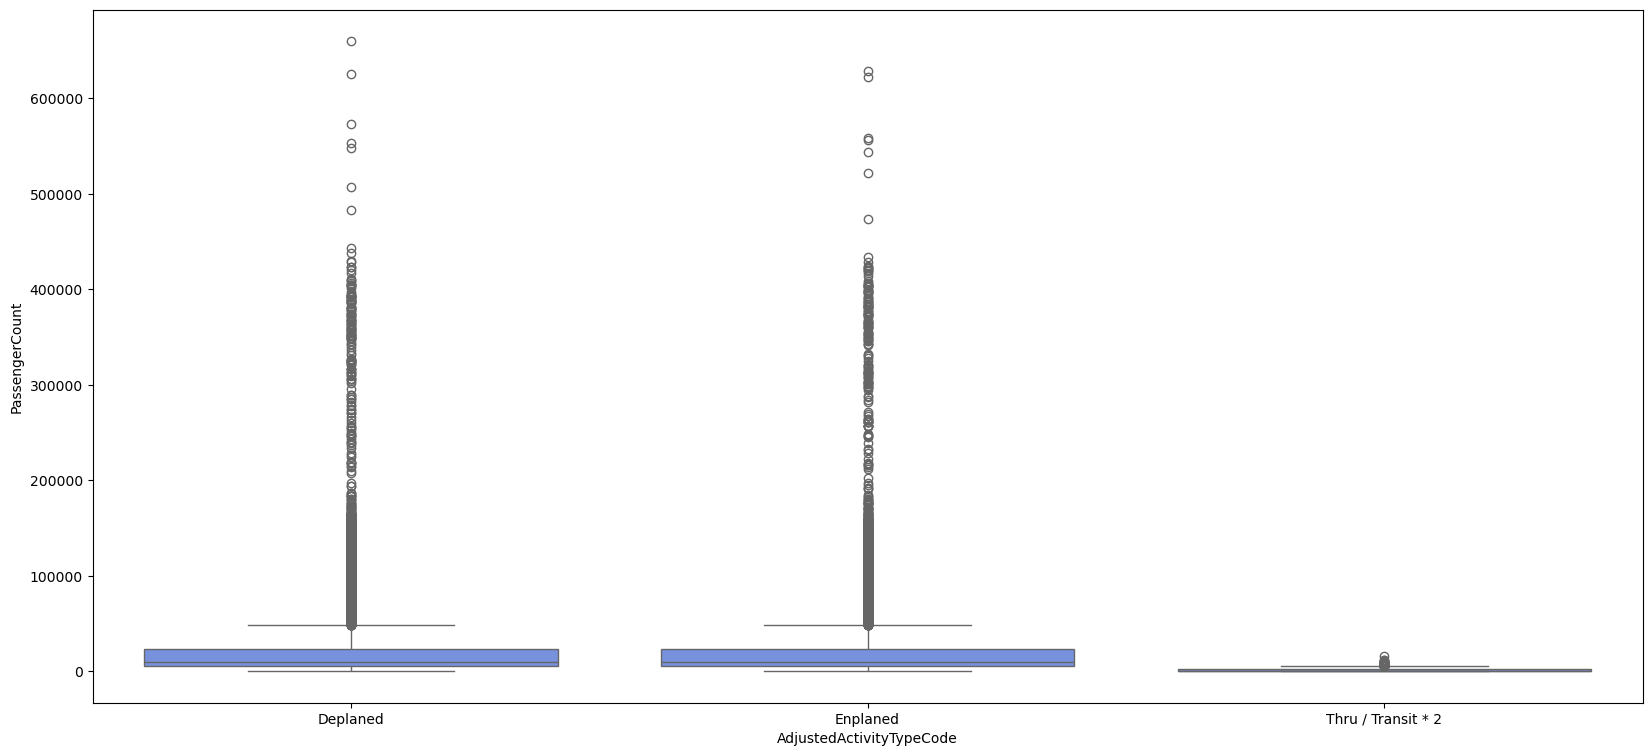

In [325]:
plt.figure(figsize = (20,9))
sb.set_palette("coolwarm")
sb.boxplot(x=df.AdjustedActivityTypeCode,y=df.PassengerCount)
plt.show()

##### The data indicates a balanced flow of passenger traffic, with nearly equal counts of passengers enplaning and deplaning across the regions. This suggests that most airports are functioning as origin and destination points, rather than transfer hubs. The significantly lower counts in the Thru/Transit category highlight that relatively few passengers are using these locations for connecting flights, implying limited hub activity or low transit passenger traffic.

### Temporal Analysis :-

In [307]:
df.Month.unique()

array(['July', 'August', 'September', 'October', 'November', 'April',
       'December', 'January', 'February', 'March', 'May', 'June'],
      dtype=object)

### How has passenger traffic evolved over the years and months?

In [577]:
df.groupby('Year')[['PassengerCount']].sum().nlargest(10, 'PassengerCount').reset_index()

,Year,PassengerCount
0,2015,50057887
1,2014,47114631
2,2013,44945760
3,2012,44399885
4,2011,40927786
5,2010,39253999
6,2009,37338942
7,2008,37234678
8,2007,35554082
9,2006,33332970


In [579]:
df.groupby('Month')[['PassengerCount']].sum().nlargest(10, 'PassengerCount').reset_index()

,Month,PassengerCount
0,August,42753659
1,July,42552115
2,October,38391386
3,June,37721908
4,September,37256777
5,March,36787839
6,December,36162507
7,May,35558969
8,November,34988575
9,April,33106801


In [310]:
data_traffic = pd.pivot_table(data = df, index = 'Year', columns = 'Month',values='PassengerCount', aggfunc = 'sum')
data_traffic

Month,April,August,December,February,January,July,June,March,May,November,October,September
Year,,,,,,,,,,,,
2005,NaN,3195866.0,2671797.0,NaN,NaN,3225769.0,NaN,NaN,NaN,2617333.0,2770715.0,2740553.0
2006,2773293.0,3143839.0,2698200.0,2223024.0,2448889.0,3227605.0,3071396.0,2708778.0,2829000.0,2653887.0,2834959.0,2720100.0
2007,2869247.0,3436417.0,2903637.0,2304990.0,2507430.0,3382382.0,3263621.0,2820085.0,3056934.0,2922500.0,3129309.0,2957530.0
2008,3029021.0,3612297.0,2962937.0,2595676.0,2670053.0,3603946.0,3453751.0,3127387.0,3305954.0,2744485.0,3124451.0,3004720.0
2009,3024973.0,3650668.0,3074209.0,2359800.0,2644539.0,3649702.0,3419595.0,2925918.0,3177100.0,2971484.0,3249428.0,3191526.0
2010,3139059.0,3771842.0,3167124.0,2515361.0,2785466.0,3765824.0,3612886.0,3105958.0,3380355.0,3163659.0,3490100.0,3356365.0
2011,3200527.0,3917884.0,3441693.0,2610667.0,2883810.0,3935589.0,3766323.0,3129205.0,3547804.0,3326859.0,3602455.0,3564970.0
2012,3563007.0,4356216.0,3443039.0,2998119.0,3211600.0,4284443.0,4107195.0,3472440.0,3820570.0,3478890.0,3844987.0,3819379.0
2013,3604104.0,4347059.0,3814984.0,2966477.0,3204637.0,4176486.0,4146797.0,3593364.0,3933016.0,3466878.0,3910790.0,3781168.0


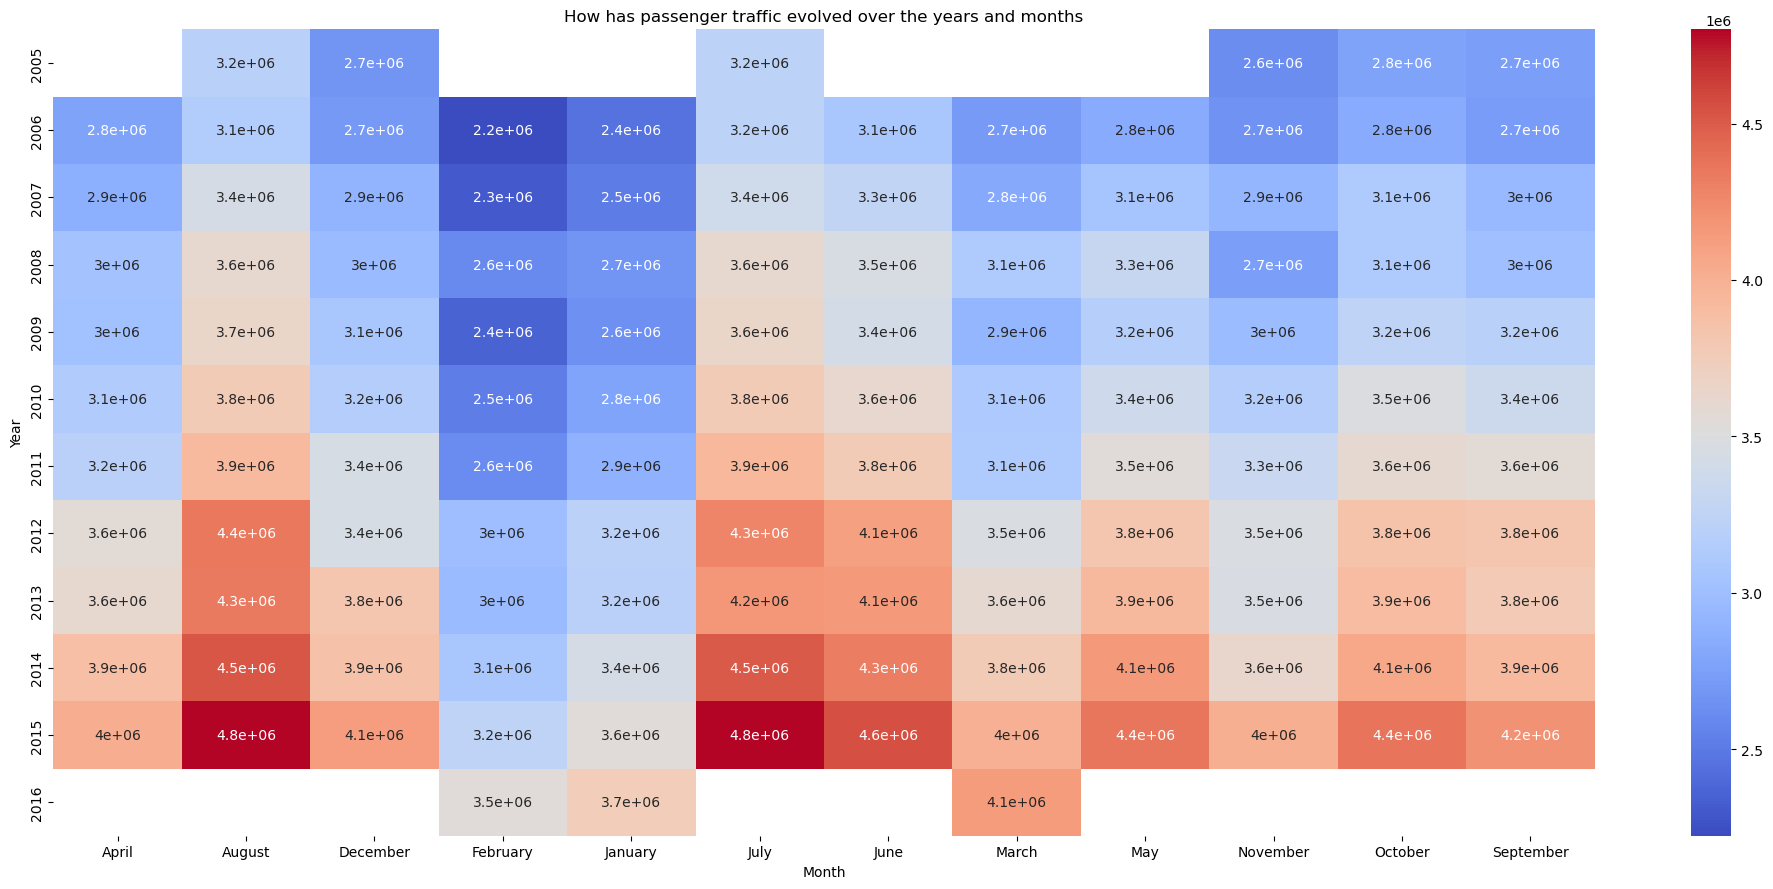

In [311]:
plt.figure(figsize=(20, 9))
sb.heatmap(data_traffic, annot=True, cmap= "coolwarm")
plt.title("How has passenger traffic evolved over the years and months")
plt.tight_layout()
plt.show()

##### July 2015 recorded the highest passenger volume, suggesting a seasonal peak during the summer months.
##### The passenger count shows a significant increase during the summer months, particularly in June, July, and August. This seasonal spike suggests higher travel activity during summer, likely driven by vacation plans, tourism, and school breaks. Airlines and airports may need to allocate additional resources during this period to handle the increased volume efficiently.

### Are there specific months or seasons that show peak or low passenger traffic?

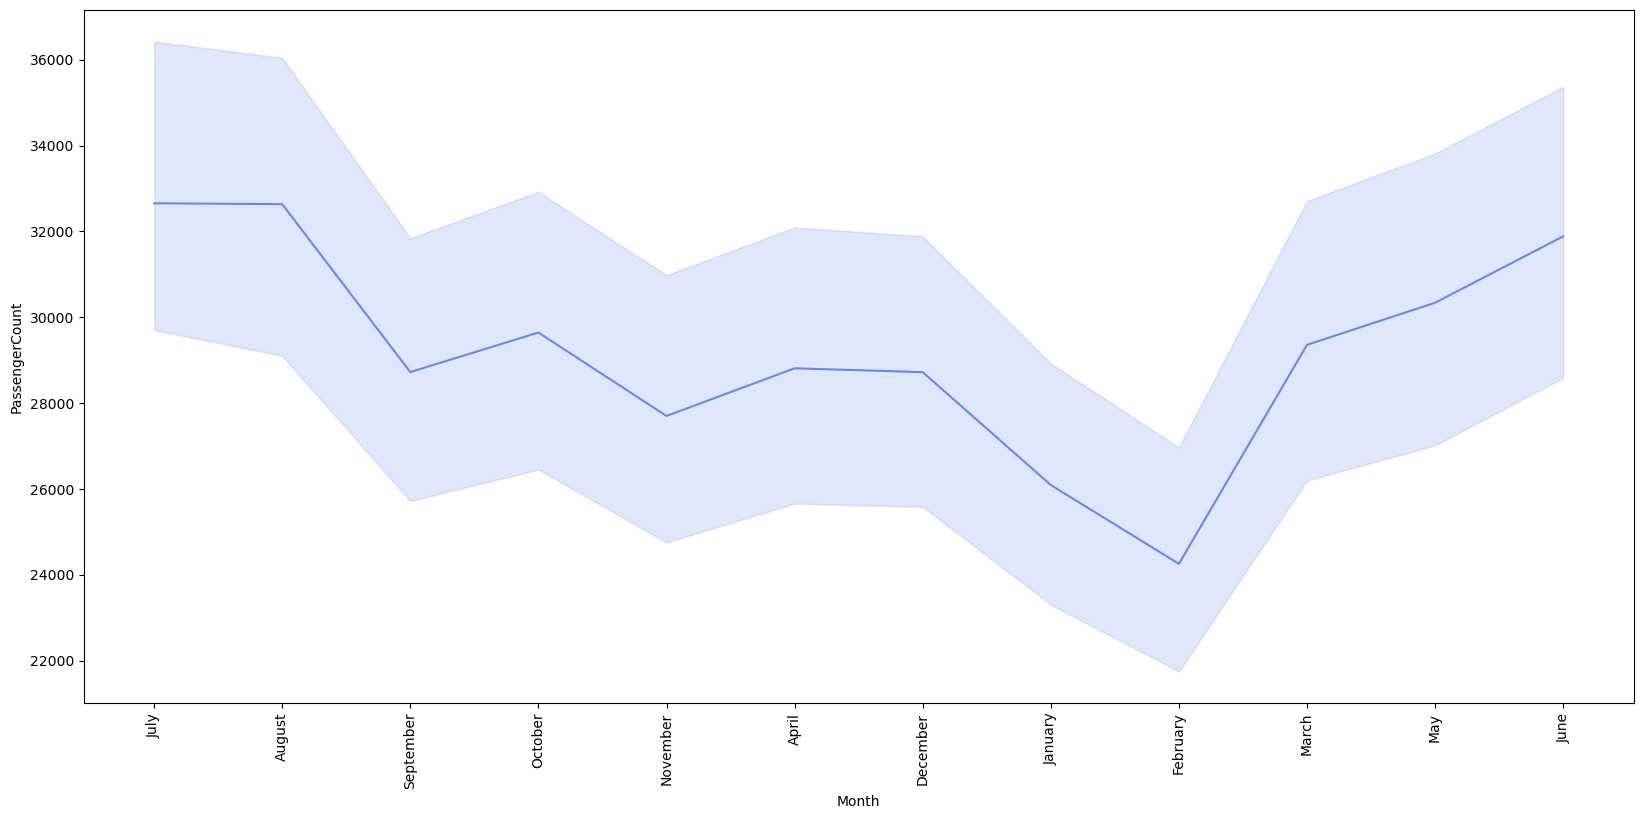

In [504]:
plt.figure(figsize = (20, 9))
sb.set_palette("coolwarm")
sb.lineplot(x = df.Month, y = df.PassengerCount)
plt.xticks(rotation = 90)
plt.show()

##### In each year, there is a consistent increase in passenger count from May to August, highlighting a strong seasonal trend. This pattern suggests that late summer months experience the highest travel activity, possibly due to holidays, tourism, and end-of-summer travel plans.

### What trends can be identified from year-over-year passenger data?

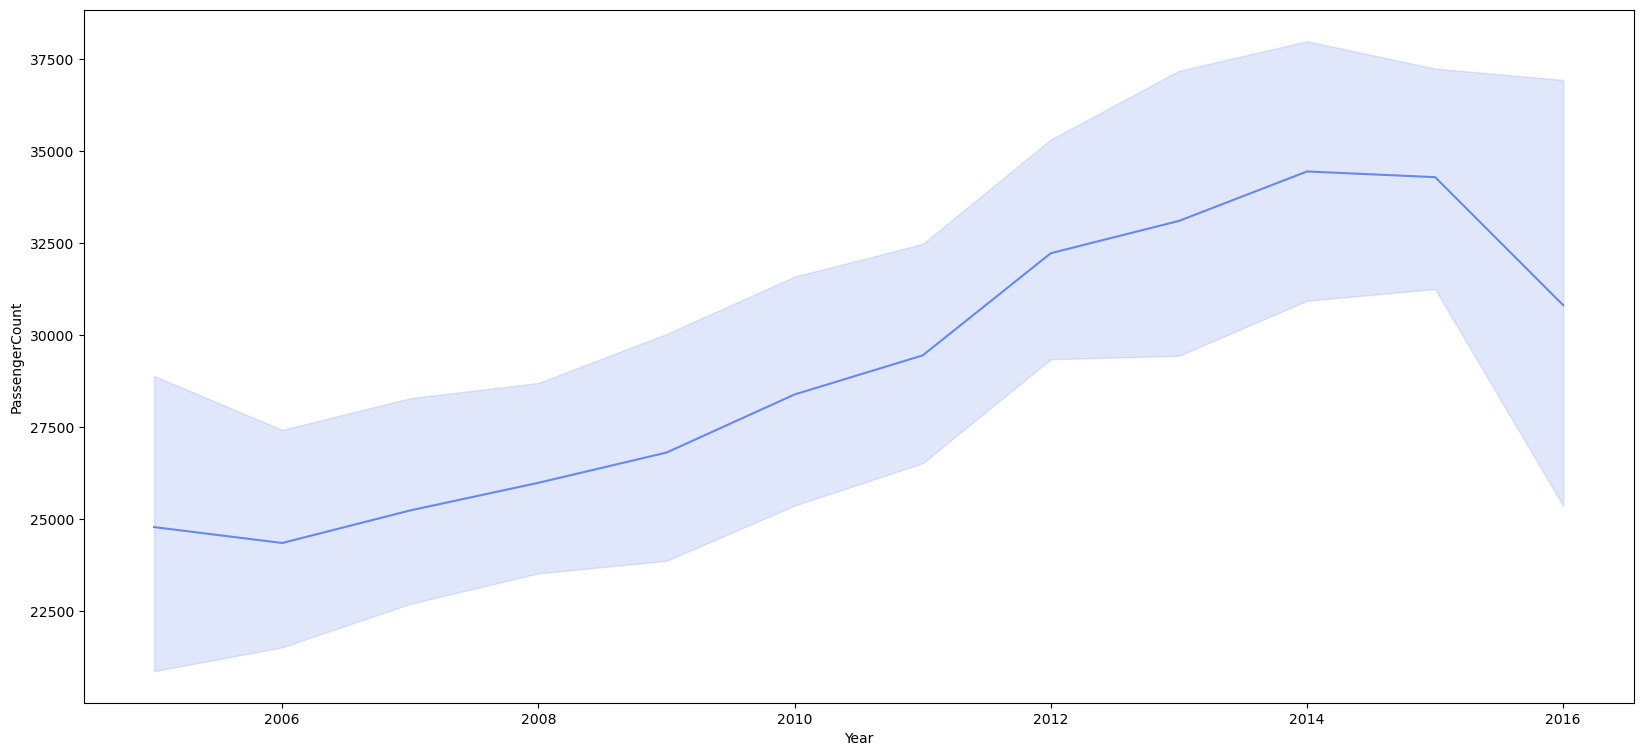

In [503]:
plt.figure(figsize = (20, 9))
sb.set_palette("coolwarm")
sb.lineplot(x = df.Year, y = df.PassengerCount)
plt.show()

##### Between 2014 and 2015, the data shows the highest passenger volumes, indicating a peak in air travel demand during this period. 
##### The Obesrvation reveals a consistent year-over-year growth in passenger traffic, indicating a positive trend in air travel demand

In [313]:
df.Terminal.unique()

array(['Terminal 1', 'International', 'Terminal 3', 'Other', 'Terminal 2'],
      dtype=object)

### Airline Analysis
##### Which airlines handle the highest and lowest number of passengers?

,Top_Operating_Airline,Top_Passenger_Count,Bottom_Operating_Airline,Bottom_Passenger_Count
0,United Airlines,170240913,Evergreen International Airlines,4
1,SkyWest Airlines,35711737,Boeing Company,18
2,American Airlines,34588714,"Atlas Air, Inc",68
3,Virgin America,26934738,Ameriflight,110
4,Delta Air Lines,26440420,Xtra Airways,146
5,Southwest Airlines,25087141,Pacific Aviation,320
6,US Airways,16816616,World Airways,785
7,Alaska Airlines,12955980,Miami Air International,1718
8,JetBlue Airways,7827973,Servisair,3242
9,Air Canada,6680071,Swissport USA,3879


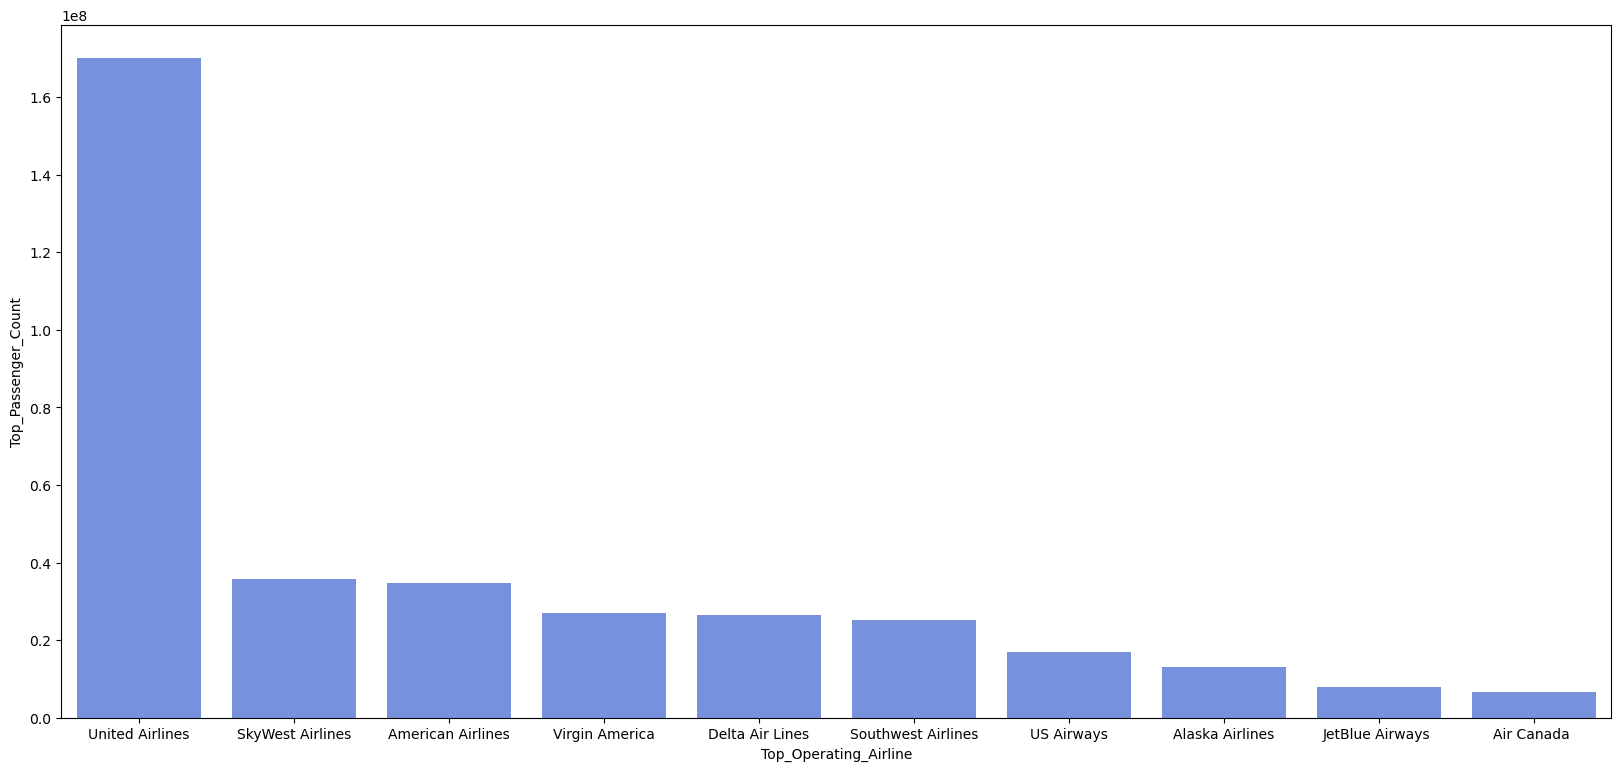

In [513]:
d = df.groupby('OperatingAirline')['PassengerCount'].sum().nlargest(10).reset_index()
z = df.groupby('OperatingAirline')['PassengerCount'].sum().nsmallest(10).reset_index()

d.columns = ['Top_Operating_Airline', 'Top_Passenger_Count']
z.columns = ['Bottom_Operating_Airline', 'Bottom_Passenger_Count']
result = pd.concat([d, z], axis = 1)
display(result)

plt.figure(figsize = (20,9))
sb.barplot(x = d.Top_Operating_Airline, y = d.Top_Passenger_Count)
plt.show()

##### United Airlines stands out as the leading carrier in terms of passenger volume, significantly surpassing all other airlines in the dataset. On the other hand, Evergreen International Airlines accounts for the lowest passenger traffic, indicating a much smaller operational scale or limited route coverage. This contrast highlights the dominance of major carriers in handling air traffic compared to niche or less active airlines.

### Terminal and Boarding Area Analysis

#### Is there a notable difference in usage between terminals or boarding areas?

,Terminal,BoardingArea,PassengerCount
0,Terminal 3,F,138526673
1,Terminal 1,B,67373108
2,International,A,57670570
3,International,G,57613844
4,Terminal 1,C,42271640
5,Terminal 3,E,40886909
6,Terminal 2,D,34060240
7,Terminal 1,A,409316
8,Other,Other,200


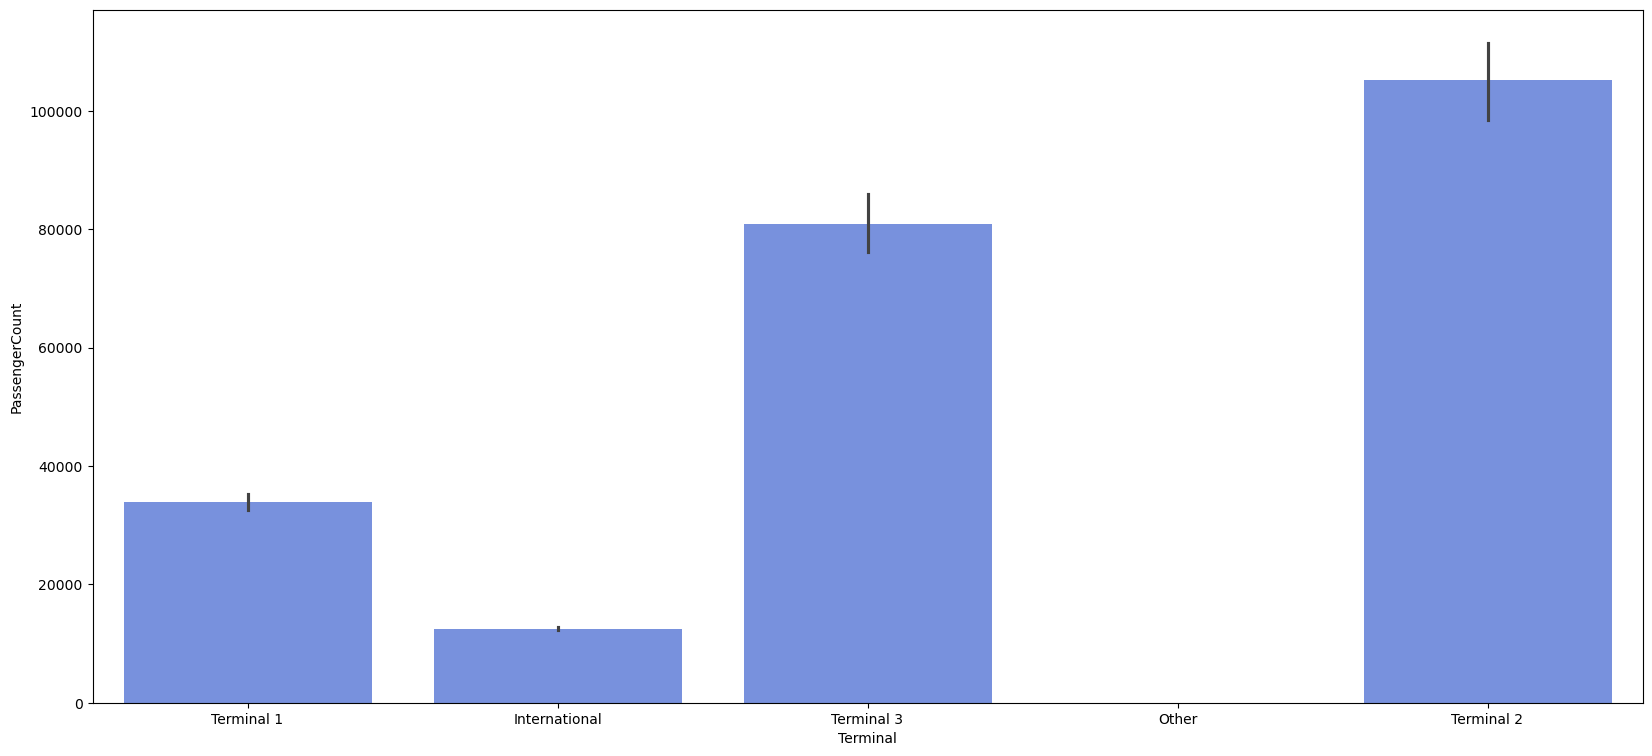

In [517]:
t = df.groupby(['Terminal', 'BoardingArea'])[['PassengerCount']].sum().nlargest(10, 'PassengerCount').reset_index()
display(t)

plt.figure(figsize = (20,9))
sb.set_palette("coolwarm")
sb.barplot(x = df.Terminal , y = df.PassengerCount)
plt.show()

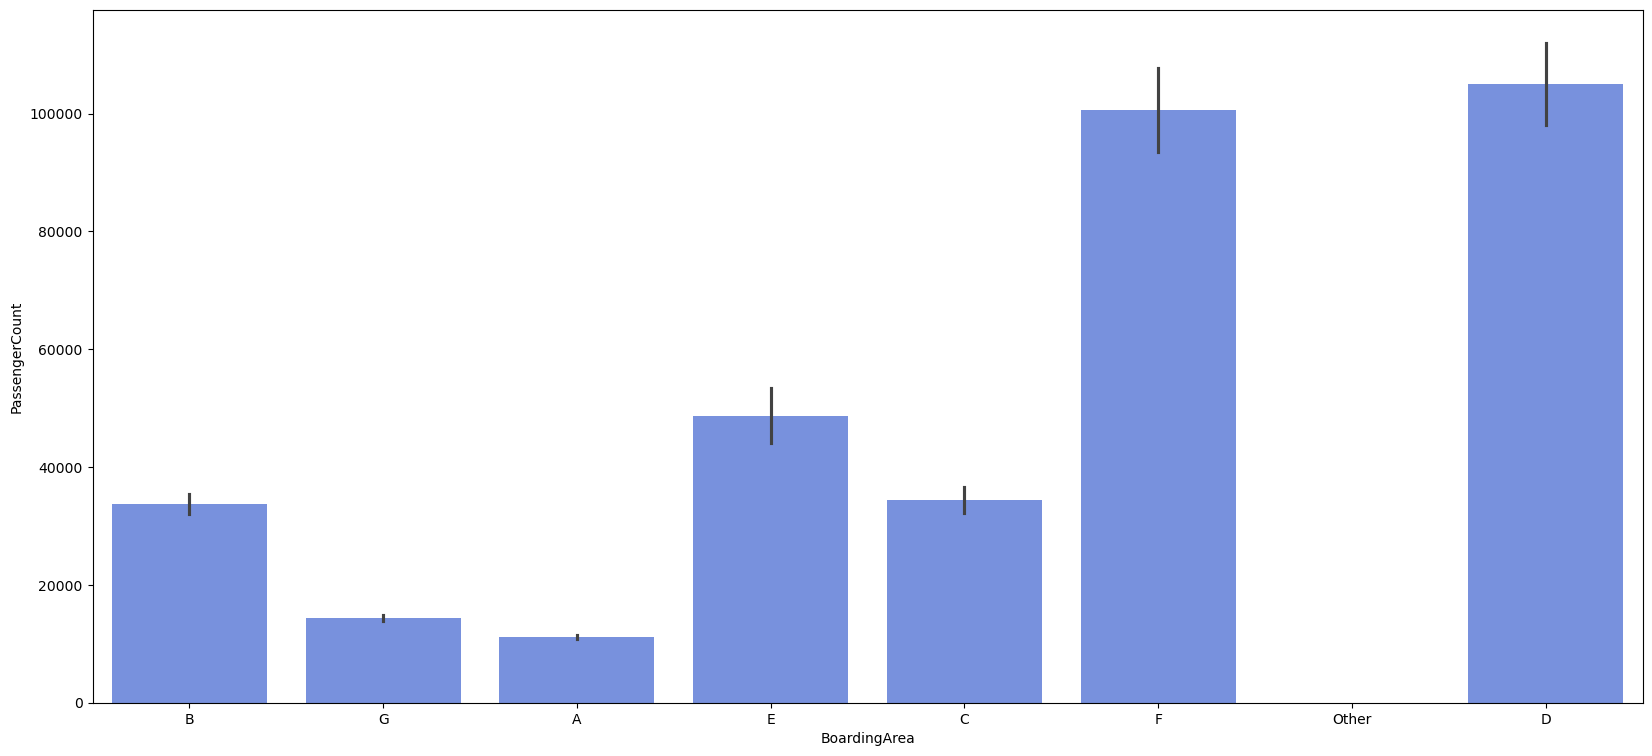

In [516]:
plt.figure(figsize = (20,9))
sb.set_palette("coolwarm")
sb.barplot(x = df.BoardingArea , y = df.PassengerCount)
# plt.xticks(rotation = 90)
plt.show()

##### Terminal 3 records the highest overall passenger count across all terminals, with Boarding Area F being its major contributor. However, when comparing across all boarding areas, Boarding Area D stands out with the highest passenger count overall, indicating its prominence regardless of terminal association.

In [319]:
df.BoardingArea.unique()

array(['B', 'G', 'A', 'E', 'C', 'F', 'Other', 'D'], dtype=object)

####  Which terminals and boarding areas are the busiest in terms of passenger traffic?

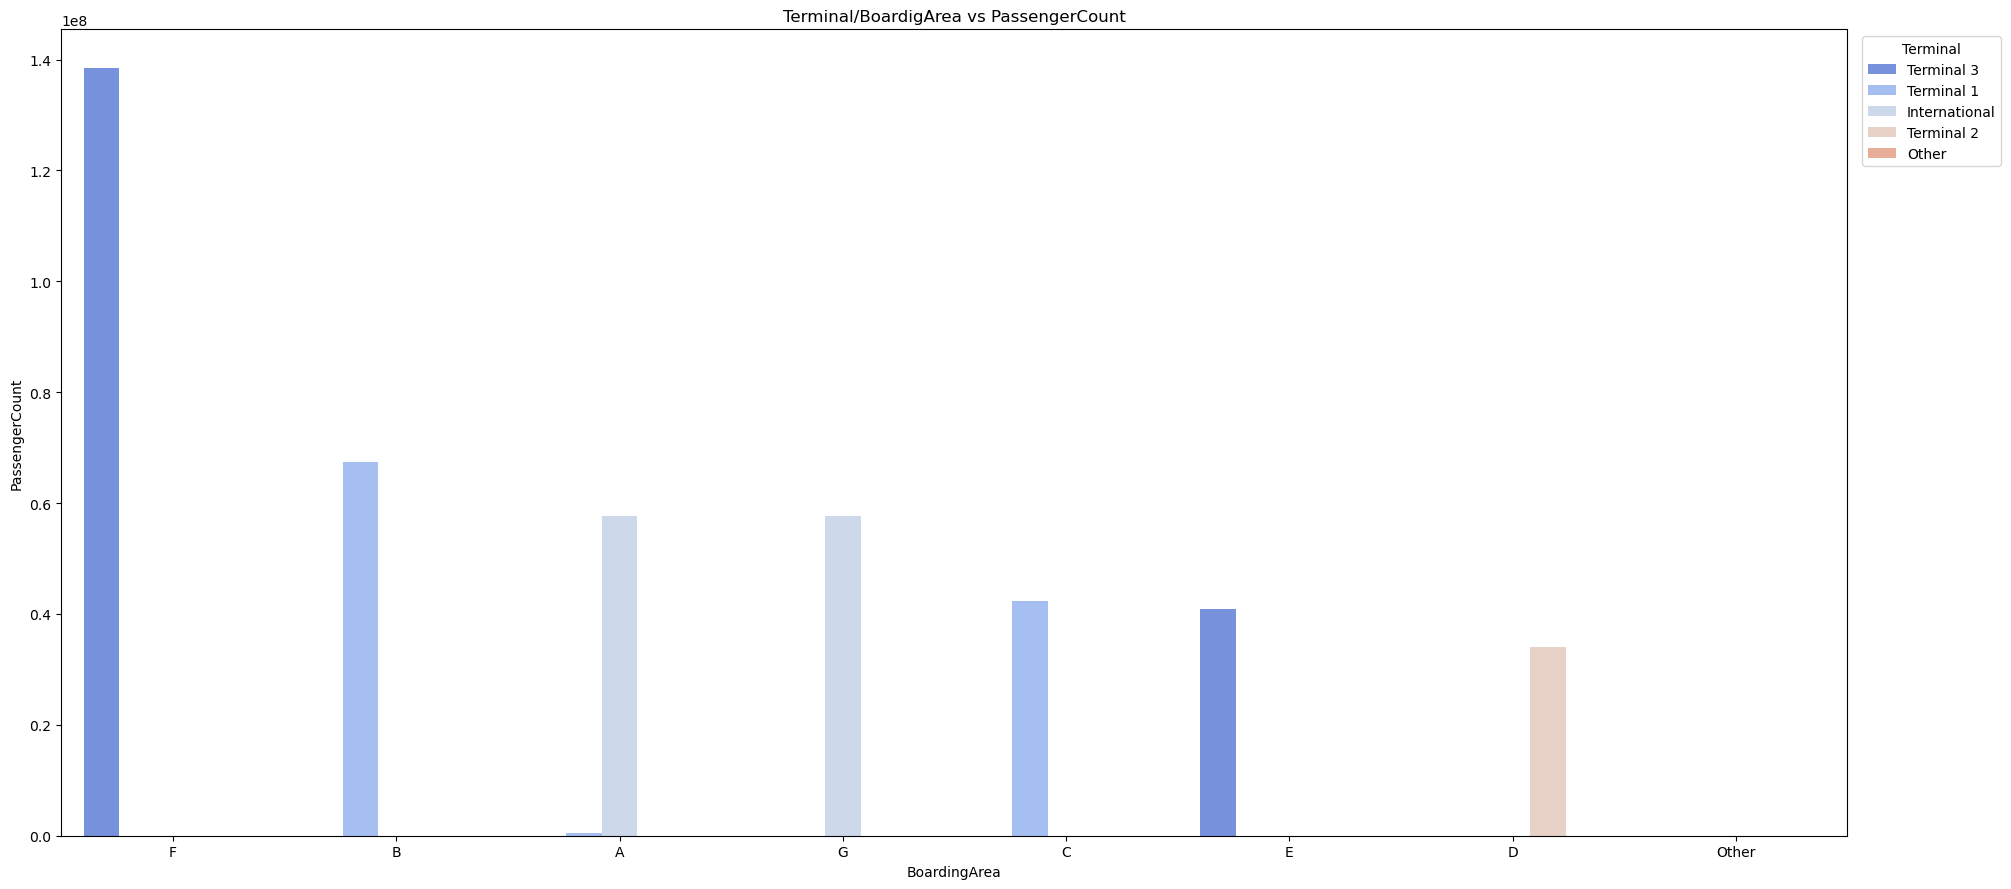

In [545]:
g = df.groupby(['Terminal', 'BoardingArea'])[['PassengerCount']].sum().nlargest(10, 'PassengerCount').reset_index()
plt.figure(figsize = (20,9))
sb.barplot(x = g.BoardingArea, y = g.PassengerCount, hue = g.Terminal)
plt.title("Terminal/BoardigArea vs PassengerCount")
plt.legend(title='Terminal',bbox_to_anchor=(1.09,1.0))
plt.tight_layout()
plt.show()

##### Terminal 3 records the highest overall passenger count across all terminals, with Boarding Area F and is busiets interms of Passenger counts